# Introduction

This notebook implements the **segmentation stage** of the project: training and applying a UNet model (MONAI/PyTorch) to fetal vein ultrasound data. Within the overall pipeline, it translates pre-processed and original image sets into pixel-wise predictions and persisted model checkpoints, forming the bridge between dataset conditioning (pre-processing) and quantitative assessment (evaluation).

The scientific objective is to measure how alternative pre-processing strategies influence segmentation performance when all other training choices are held consistent. The same architecture, optimisation schedule, and data split logic are applied to the original images and to each pre-processed variant (PP1–PP5), so observed differences in masks and validation scores can be attributed primarily to input conditioning rather than to ad hoc training changes.

**Inputs:** image folders (`images/` or `images_pp_N/`) with paired labels in `02_dataset/labels/`. **Outputs:** best model weights under `Save_Models/` and binary prediction masks in the configured `results_*` directories. These outputs are consumed by the evaluation notebook for metric computation with and without morphological post-processing.


# Dependencies

All third-party and standard-library imports for this notebook are declared here.
Downstream cells must not repeat these imports.

## Import groups

Standard library, NumPy, Matplotlib, PIL, PyTorch, and MONAI (transforms, UNet, metrics, dataloaders).


In [1]:
%matplotlib inline

# --- Standard library ---
import glob
import os
import re
import shutil
import tempfile
import time
from pathlib import Path

# --- Numerical computing ---
import numpy as np

# --- Image I/O and visualisation ---
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from PIL import Image

# --- Deep learning (PyTorch + MONAI) ---
import torch
from monai.config import print_config
from monai.data import CacheDataset, DataLoader, Dataset, decollate_batch, list_data_collate
from monai.handlers.utils import from_engine
from monai.inferers import sliding_window_inference
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    Activationsd,
    AsDiscrete,
    AsDiscreted,
    Compose,
    Invertd,
    LoadImaged,
    MapTransform,
    NormalizeIntensityd,
    Orientationd,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandSpatialCropd,
    Spacingd,
    EnsureTyped,
    EnsureChannelFirstd,
    ScaleIntensityRanged,
    SpatialPadd,
)
from monai.utils import set_determinism
import pdb


Reusable helpers, experiment configuration, and MONAI pipeline blocks follow.
Execute cells **top to bottom** from a clean kernel (`Run All`).


# Experiment Configuration

| Experiment | DATASET_FOLDER | RESULTS_FOLDER | MODEL_NAME |
|------------|----------------|----------------|------------|
| Original | images | results_original | best_metric_model_original.pth |
| PP1 | images_pp_1 | results_pp_1 | best_metric_model_pp_1.pth |
| PP2 | images_pp_2 | results_pp_2 | best_metric_model_pp_2.pth |
| PP3 | images_pp_3 | results_pp_3 | best_metric_model_pp_3.pth |
| PP4 | images_pp_4 | results_pp_4 | best_metric_model_pp_4.pth |
| PP5 | images_pp_5 | results_pp_5 | best_metric_model_pp_5.pth |


In [2]:
# ==========================================================
# SEGMENTATION EXPERIMENT CONFIGURATION
# ==========================================================

EXPERIMENT_ID = 5
DATASET_FOLDER = "images_pp_5"
RESULTS_FOLDER = "results_pp_5"
MODEL_NAME = "best_metric_model_pp_5.pth"

# Train / validation / test split (same as lecturer notebook)
TRAIN_COUNT = 110
VAL_COUNT = 20


# 5. Experimental Configurations

Change **§1.3** only between runs. Execution order: Original → PP1 → … → PP5 as needed.


## Original

**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

- **Dataset source:** `02_dataset/images/`
- **Model inputs:** paired images + `02_dataset/labels/`
- **Generated outputs:** `02_dataset/results_original/`, `02_dataset/Save_Models/best_metric_model_original.pth`
- **Experimental purpose:** Baseline ultrasound set.

```python
DATASET_FOLDER = "images"
RESULTS_FOLDER = "results_original"
MODEL_NAME = "best_metric_model_original.pth"
```


## PP1

**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

- **Dataset source:** `02_dataset/images_pp_1/`
- **Model inputs:** paired images + `02_dataset/labels/`
- **Generated outputs:** `02_dataset/results_pp_1/`, `02_dataset/Save_Models/best_metric_model_pp_1.pth`
- **Experimental purpose:** Average-filter preprocessing.

```python
DATASET_FOLDER = "images_pp_1"
RESULTS_FOLDER = "results_pp_1"
MODEL_NAME = "best_metric_model_pp_1.pth"
```


## PP2

**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

- **Dataset source:** `02_dataset/images_pp_2/`
- **Model inputs:** paired images + `02_dataset/labels/`
- **Generated outputs:** `02_dataset/results_pp_2/`, `02_dataset/Save_Models/best_metric_model_pp_2.pth`
- **Experimental purpose:** Median-filter preprocessing.

```python
DATASET_FOLDER = "images_pp_2"
RESULTS_FOLDER = "results_pp_2"
MODEL_NAME = "best_metric_model_pp_2.pth"
```


## PP3

**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

- **Dataset source:** `02_dataset/images_pp_3/`
- **Model inputs:** paired images + `02_dataset/labels/`
- **Generated outputs:** `02_dataset/results_pp_3/`, `02_dataset/Save_Models/best_metric_model_pp_3.pth`
- **Experimental purpose:** Gaussian-filter preprocessing.

```python
DATASET_FOLDER = "images_pp_3"
RESULTS_FOLDER = "results_pp_3"
MODEL_NAME = "best_metric_model_pp_3.pth"
```


## PP4

**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

- **Dataset source:** `02_dataset/images_pp_4/`
- **Model inputs:** paired images + `02_dataset/labels/`
- **Generated outputs:** `02_dataset/results_pp_4/`, `02_dataset/Save_Models/best_metric_model_pp_4.pth`
- **Experimental purpose:** Sobel-filter preprocessing.

```python
DATASET_FOLDER = "images_pp_4"
RESULTS_FOLDER = "results_pp_4"
MODEL_NAME = "best_metric_model_pp_4.pth"
```


## PP5

**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

- **Dataset source:** `02_dataset/images_pp_5/`
- **Model inputs:** paired images + `02_dataset/labels/`
- **Generated outputs:** `02_dataset/results_pp_5/`, `02_dataset/Save_Models/best_metric_model_pp_5.pth`
- **Experimental purpose:** Laplacian-filter preprocessing.

```python
DATASET_FOLDER = "images_pp_5"
RESULTS_FOLDER = "results_pp_5"
MODEL_NAME = "best_metric_model_pp_5.pth"
```


# Dataset Validation Functions

Identifier-based pairing (never by list index).


### `find_project_root()`

**Description:** See implementation.
**Parameters:** See signature.
**Returns:** See docstring.
**Usage context:** Dataset preparation (§5).



In [3]:
def find_project_root(start_path: Path) -> Path:
    """Walk up the directory tree until 02_dataset/ is found."""
    for candidate_path in [start_path, *start_path.parents]:
        if (candidate_path / "02_dataset").is_dir():
            return candidate_path
    raise FileNotFoundError(
        f"Directory 02_dataset/ not found from {start_path}. "
        "Run the notebook from the fetal_vein_segmentation repository."
    )

PP_SUFFIX_PATTERN = re.compile(r"_PP_PL_\d+$", re.IGNORECASE)
PATIENT_ID_PATTERN = re.compile(r"^P\d+", re.IGNORECASE)



### `extract_base_identifier()`

**Description:** See implementation.
**Parameters:** See signature.
**Returns:** See docstring.
**Usage context:** Dataset preparation (§5).



In [4]:
def extract_base_identifier(file_name: str) -> str:
    """
    Original image identifier (without preprocessing suffix).
    Ex.: P080_IMG1_PP_PL_1.png → P080_IMG1; P080_IMG1.png → P080_IMG1.
    """
    stem = Path(file_name).stem
    original_identifier = PP_SUFFIX_PATTERN.sub("", stem)
    if not original_identifier or not PATIENT_ID_PATTERN.match(original_identifier):
        raise ValueError(
            f"Invalid original identifier in '{file_name}'. "
            f"Expected format P080_IMG1 or P080_IMG1_PP_PL_N."
        )
    return original_identifier



### `resolve_label_path()`

**Description:** See implementation.
**Parameters:** See signature.
**Returns:** See docstring.
**Usage context:** Dataset preparation (§5).



In [5]:
def resolve_label_path(prediction_file_name: str, labels_dir: Path) -> Path:
    """Maps image/prediction to ground truth in labels/ using the original identifier."""
    original_identifier = extract_base_identifier(prediction_file_name)
    candidate_path = labels_dir / f"{original_identifier}.png"
    if candidate_path.is_file():
        return candidate_path
    raise FileNotFoundError(
        f"Missing label for '{prediction_file_name}' (ID original {original_identifier}). "
        f"Expected: {candidate_path}"
    )



### `validate_pairing_folder()`

**Description:** See implementation.
**Parameters:** See signature.
**Returns:** See docstring.
**Usage context:** Dataset preparation (§5).



In [6]:
def validate_pairing_folder(images_folder: Path, labels_dir: Path) -> list:
    """Validates each image/prediction → label by ID (not by index)."""
    pairing_errors = []
    if not images_folder.is_dir():
        return [f"Folder does not exist: {images_folder}"]
    for image_path in sorted(images_folder.glob("*.png")):
        try:
            resolve_label_path(image_path.name, labels_dir)
        except (ValueError, FileNotFoundError) as exc:
            pairing_errors.append(f"{image_path.name}: {exc}")
    return pairing_errors



### `build_data_dicts()`

**Description:** Build MONAI file list with labels.
**Parameters:** images_folder
**Returns:** list of dicts
**Usage context:** §5



In [7]:
def build_data_dicts(images_folder: Path) -> list:
    """Pairs each image with its label using the original identifier."""
    images_list = sorted(glob.glob(str(images_folder / "*.png")))
    if len(images_list) == 0:
        raise FileNotFoundError(f"No .png images in {images_folder}")

    pares = []
    for image_path in images_list:
        label_path = resolve_label_path(Path(image_path).name, LABELS_DIR)
        pares.append({"image": image_path, "label": str(label_path)})

    return pares


# Project Paths

Resolved from `DATASET_FOLDER` and experiment settings above.


In [8]:
PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_DIR = PROJECT_ROOT / "02_dataset"
IMAGES_DIR = DATA_DIR / DATASET_FOLDER
LABELS_DIR = DATA_DIR / "labels"
SAVE_MODELS_DIR = DATA_DIR / "Save_Models"
RESULTS_DIR = DATA_DIR / RESULTS_FOLDER

for output_dir in (SAVE_MODELS_DIR, RESULTS_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

print(f"Experiment: {EXPERIMENT_ID}")
print(f"Root: {PROJECT_ROOT}")
print(f"Images: {IMAGES_DIR}")
print(f"Labels: {LABELS_DIR}")
print(f"Model: {SAVE_MODELS_DIR / MODEL_NAME}")
print(f"Predictions: {RESULTS_DIR}")


Experiment: 5
Root: C:\AA_trabalho\fetal_vein_segmentation
Images: C:\AA_trabalho\fetal_vein_segmentation\02_dataset\images_pp_5
Labels: C:\AA_trabalho\fetal_vein_segmentation\02_dataset\labels
Model: C:\AA_trabalho\fetal_vein_segmentation\02_dataset\Save_Models\best_metric_model_pp_5.pth
Predictions: C:\AA_trabalho\fetal_vein_segmentation\02_dataset\results_pp_5


# Dataset Preparation

Validate image–label pairing and build train/val/test file lists.


In [9]:
# Pre-training pairing validation
pairing_errors = validate_pairing_folder(IMAGES_DIR, LABELS_DIR)
if pairing_errors:
    raise RuntimeError(
        "Image–label pairing failed. First errors:\n"
        + "\n".join(pairing_errors[:10])
    )

data_dicts = build_data_dicts(IMAGES_DIR)
train_files = data_dicts[:TRAIN_COUNT]
val_files = data_dicts[TRAIN_COUNT : TRAIN_COUNT + VAL_COUNT]
test_files = data_dicts[TRAIN_COUNT + VAL_COUNT :]

print(f"Total pairs: {len(data_dicts)}")
print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")
print(f"Device is set in the model section.")



Total pairs: 152
Train: 110 | Val: 20 | Test: 22
Device is set in the model section.


# MONAI Transforms and DataLoaders

Transforms, datasets, and dataloaders.


In [10]:
print_config()


MONAI version: 1.5.2
Numpy version: 2.4.6
Pytorch version: 2.11.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: C:\AA_trabalho\fetal_vein_segmentation\.venv\Lib\site-packages\monai\__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: 0.26.0
scipy version: 1.17.1
Pillow version: 12.2.0
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.26.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: 3.0.3
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN 

## Set deterministic training for reproducibility

In [11]:
set_determinism(seed=0)


In [12]:
train_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=False),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image", "label"],
            a_min=0,
            a_max=255,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
    ]
)

val_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=False),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image", "label"],
            a_min=0,
            a_max=255,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
    ]
)

test_transform = Compose(
    [
        LoadImaged(keys=["image", "label"], image_only=False),
        EnsureChannelFirstd(keys=["image", "label"]),
        ScaleIntensityRanged(
            keys=["image", "label"],
            a_min=0,
            a_max=255,
            b_min=0.0,
            b_max=1.0,
            clip=True,
        ),
    ]
)


## Create Datasets

In [13]:
train_ds = Dataset(data=train_files, transform=train_transform)
train_loader = DataLoader(
    train_ds, batch_size=10, shuffle=True, num_workers=0, collate_fn=list_data_collate
)

val_ds = Dataset(data=val_files, transform=val_transform)
val_loader = DataLoader(
    val_ds, batch_size=5, shuffle=False, num_workers=0, collate_fn=list_data_collate
)

test_ds = Dataset(data=test_files, transform=test_transform)
test_loader = DataLoader(
    test_ds, batch_size=1, shuffle=False, num_workers=0, collate_fn=list_data_collate
)


# Model Configuration

UNet, loss, optimizer, and validation metrics (lecturer-aligned settings).


In [14]:
max_epochs = 150
val_interval = 1
VAL_AMP = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = UNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

loss_function = DiceLoss(
    smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True
)
optimizer = torch.optim.Adam(model.parameters(), 1e-2)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])


Using device: cuda


**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

**Purpose:** Training loop with validation Dice for checkpoint selection.
**Inputs:** Train/val loaders; device.
**Outputs:** Best and last `.pth` checkpoints.
**Dependencies:** §2 model and loaders.
**Role:** Fits UNet weights; saves best model by validation Dice.



# Training Execution

Training loop with validation Dice for checkpoint selection.


In [15]:
best_metric = -1
best_metric_epoch = -1
best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
val_values = []

best_model_path = SAVE_MODELS_DIR / MODEL_NAME
file_path_ultimo_modelo = SAVE_MODELS_DIR / f"last_{MODEL_NAME}"

total_start = time.time()

for epoch in range(max_epochs):
    epoch_start = time.time()
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        print(
            f"{step}/{len(train_ds) // train_loader.batch_size}"
            f", train_loss: {loss.item():.4f}"
            f", step time: {(time.time() - step_start):.4f}"
        )

    lr_scheduler.step()

    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)

    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                val_outputs = model(val_inputs)

                loss_val = loss_function(val_outputs, val_labels)

                val_outputs = torch.sigmoid(val_outputs)
                val_outputs = val_outputs > 0.5

                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            val_values.append(loss_val)
            metric_batch = dice_metric_batch.aggregate()

            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(model.state_dict(), best_model_path)
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f"\nbest mean dice: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
    print(f"time consuming of epoch {epoch + 1} is: {(time.time() - epoch_start):.4f}")
    torch.save(model.state_dict(), file_path_ultimo_modelo)

total_time = time.time() - total_start
print(f"Training finished in {total_time:.1f}s. Best model: {best_model_path}")


----------
epoch 1/150
1/11, train_loss: 0.9569, step time: 0.4789
2/11, train_loss: 0.9456, step time: 0.0614
3/11, train_loss: 0.9344, step time: 0.0614
4/11, train_loss: 0.9502, step time: 0.0597
5/11, train_loss: 0.9399, step time: 0.0606
6/11, train_loss: 0.9460, step time: 0.0602
7/11, train_loss: 0.9383, step time: 0.0593
8/11, train_loss: 0.9381, step time: 0.0596
9/11, train_loss: 0.9484, step time: 0.0594
10/11, train_loss: 0.9426, step time: 0.0604
11/11, train_loss: 0.9436, step time: 0.0647
epoch 1 average loss: 0.9440
saved new best metric model
current epoch: 1 current mean dice: 0.0247
best mean dice: 0.0247 at epoch: 1
time consuming of epoch 1 is: 2.0539
----------
epoch 2/150
1/11, train_loss: 0.9482, step time: 0.0626
2/11, train_loss: 0.9357, step time: 0.0623
3/11, train_loss: 0.9402, step time: 0.0649
4/11, train_loss: 0.9378, step time: 0.0634
5/11, train_loss: 0.9528, step time: 0.0589
6/11, train_loss: 0.9336, step time: 0.0592
7/11, train_loss: 0.9279, step t

## Plot the learning curves

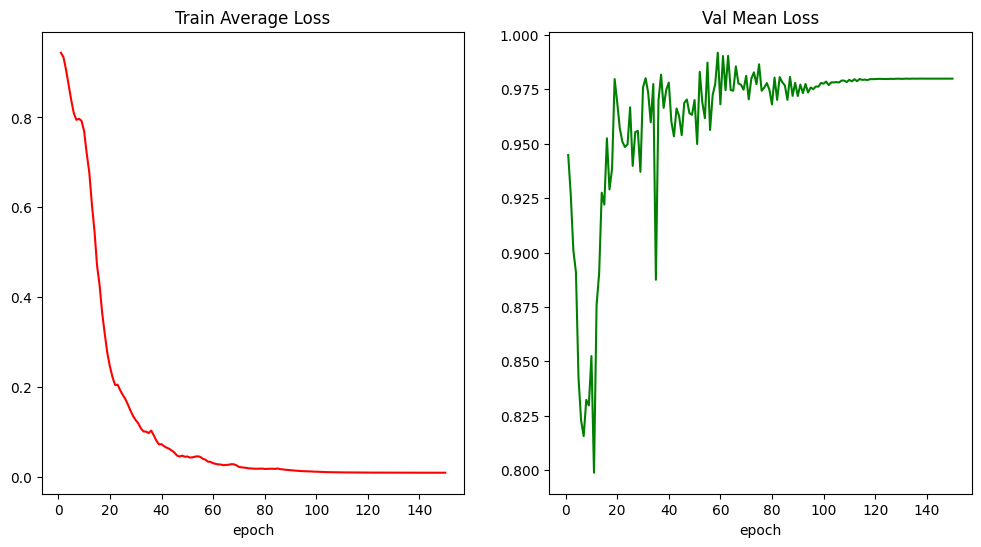

In [16]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Train Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, color="red")
plt.subplot(1, 2, 2)
plt.title("Val Mean Loss")
val_values_cpu = [t.to("cpu") for t in val_values]
x = [val_interval * (i + 1) for i in range(len(val_values_cpu))]
y = val_values_cpu
plt.xlabel("epoch")
plt.plot(x, y, color="green")
plt.show()


**Provenance:** segmentation stage (lecturer-aligned UNet/MONAI workflow).

**Purpose:** Export binary masks for the test split.
**Inputs:** Best checkpoint; test loader.
**Outputs:** PNG masks in configured `RESULTS_FOLDER`.
**Dependencies:** §3 trained weights.
**Role:** Produces mask inputs for `03_evaluation.ipynb`.



# Prediction Export

Load best checkpoint and export binary masks to `RESULTS_DIR`.


In [17]:
threshold = 0.5

list_imgs = []
list_labels = []
saved_prediction_paths = []

model.load_state_dict(torch.load(best_model_path))
model.eval()
with torch.no_grad():
    for test_data in test_loader:
        test_inputs, test_labels, meta_imagem = (
            test_data["image"].to(device),
            test_data["label"].to(device),
            test_data["image_meta_dict"],
        )
        test_outputs = model(test_inputs)
        test_outputs = torch.sigmoid(test_outputs)
        test_outputs = test_outputs > threshold

        seg = test_outputs[0, 0, :, :].cpu().numpy()
        gt = test_labels[0, 0, :, :].cpu().numpy()

        saved_prediction_paths.append(seg)
        list_labels.append(gt)
        list_imgs.append(test_inputs[0, 0, :, :].cpu().numpy())

        input_path = Path(meta_imagem["filename_or_obj"][0])
        output_path = RESULTS_DIR / input_path.name
        seg_uint8 = (seg * 255).astype("uint8")
        Image.fromarray(seg_uint8).save(output_path)

print(f"Saved {len(saved_prediction_paths)} mask(s) to {RESULTS_DIR}")


Saved 22 mask(s) to C:\AA_trabalho\fetal_vein_segmentation\02_dataset\results_pp_5


## 4.3 Sample Visualization


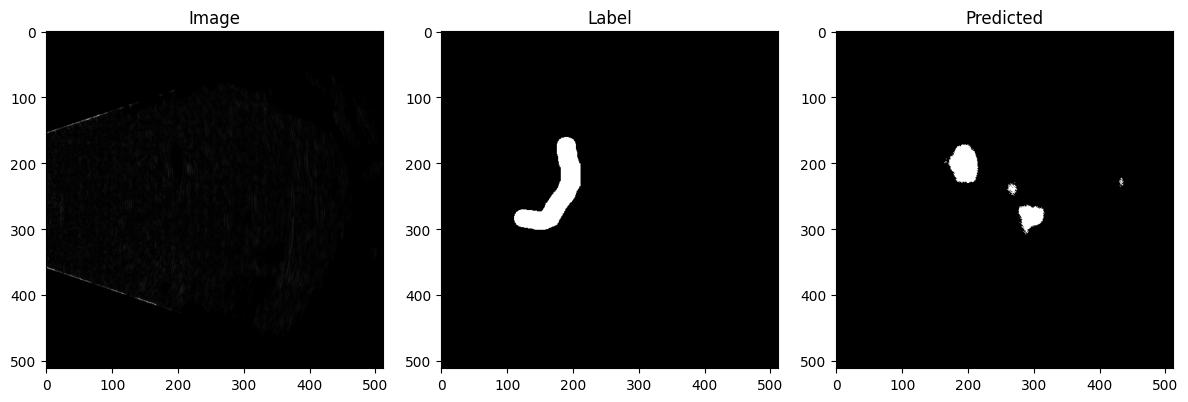

In [18]:
if len(list_imgs) > 0:
    indice = min(9, len(list_imgs) - 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(list_imgs[indice][:, :], cmap="gray")
    plt.subplot(1, 3, 2)
    plt.title("Label")
    plt.imshow(list_labels[indice][:, :], cmap="gray")
    plt.subplot(1, 3, 3)
    plt.title("Predicted")
    plt.imshow(saved_prediction_paths[indice][:, :], cmap="gray")
    plt.tight_layout()
    plt.show()


## Conclusions

Training and mask export complete for the configured experiment. Run `03_evaluation.ipynb` for metrics with and without `pos_process()`.


# 9. Outputs

`02_dataset/Save_Models/` — checkpoints;
`02_dataset/results_*` — prediction masks for `03_evaluation.ipynb`.


# 10. Conclusions

Run this notebook once per row in §4. Then open `03_evaluation.ipynb` for metrics.
